<a href="https://colab.research.google.com/github/ayushpaliwal1920/Deep_Learning/blob/main/17_zero_initialization_relu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
# generate data :

from sklearn.datasets import make_regression

x, y = make_regression(
    n_samples=100,
    n_features=2,
    noise=10,
    random_state=42
)

print(x.shape, y.shape)

(100, 2) (100,)


In [9]:
x = pd.DataFrame(x, columns=['x1', 'x2'])
y = pd.DataFrame(x,columns=["y"])

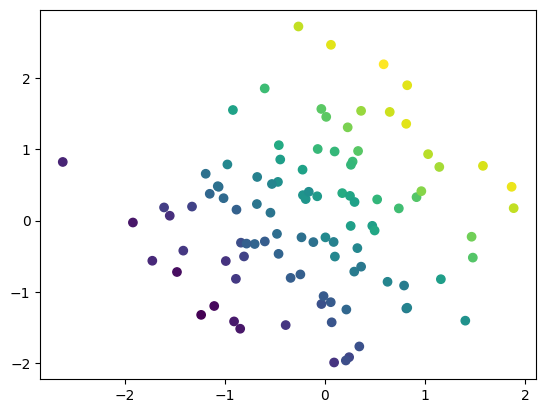

In [15]:
plt.scatter(x[:,0],x[:,1],c=y)
plt.show()

In [16]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [18]:
model = Sequential()

model.add(Dense(3,activation='relu',input_dim =2))
model.add(Dense(1,activation="sigmoid"))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 3)              │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13 (52.00 B)

 Trainable params: 13 (52.00 B)

 Non-trainable params: 0 (0.00 B)

In [19]:
#  default values :

model.get_weights()

[array([[-0.82836866, -0.13367873,  0.89647484],
        [ 0.00224817,  0.81794465,  0.501016  ]], dtype=float32),
 array([0., 0., 0.], dtype=float32),
 array([[-0.46780348],
        [ 0.82632005],
        [ 0.34415412]], dtype=float32),
 array([0.], dtype=float32)]

In [20]:
inital_weights = model.get_weights()

In [26]:
# set weights to 0

inital_weights[0] = np.zeros(model.get_weights()[0].shape)
inital_weights[1] = np.zeros(model.get_weights()[1].shape)
inital_weights[2] = np.zeros(model.get_weights()[2].shape)
inital_weights[3] = np.zeros(model.get_weights()[3].shape)


In [29]:
model.set_weights(inital_weights)

In [30]:
model.get_weights()

[array([[0., 0., 0.],
        [0., 0., 0.]], dtype=float32),
 array([0., 0., 0.], dtype=float32),
 array([[0.],
        [0.],
        [0.]], dtype=float32),
 array([0.], dtype=float32)]

In [31]:
model.compile(loss="binary_crossentropy",optimizer = "adam",metrics = ['accuracy'])

In [32]:
history = model.fit(x,y,epochs=100,validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 217ms/step - accuracy: 0.0000e+00 - loss: 0.6897 - val_accuracy: 0.0000e+00 - val_loss: 0.6749
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.0000e+00 - loss: 0.6866 - val_accuracy: 0.0000e+00 - val_loss: 0.6674
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.0000e+00 - loss: 0.6740 - val_accuracy: 0.0000e+00 - val_loss: 0.6669
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.0000e+00 - loss: 0.6743 - val_accuracy: 0.0000e+00 - val_loss: 0.6650
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.0000e+00 - loss: 0.6742 - val_accuracy: 0.0000e+00 - val_loss: 0.6646
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.0000e+00 - loss: 0.6717 - val_accuracy: 0.0000e+00 - val_loss: 0.6616
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.0000e+00 - loss: 0.6692 - val_accuracy: 0.0000e+00 - val_loss: 0.6575
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy:

In [33]:
model.get_weights()

[array([[0., 0., 0.],
        [0., 0., 0.]], dtype=float32),
 array([0., 0., 0.], dtype=float32),
 array([[0.],
        [0.],
        [0.]], dtype=float32),
 array([-0.10173668], dtype=float32)]